/var/folders/rs/z4yf99dx0wx_lqfdhc3l3dt40000gn/T/ipykernel_14621/1062770103.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis').reversed() # 深い部分を青、高い部分を黄色に


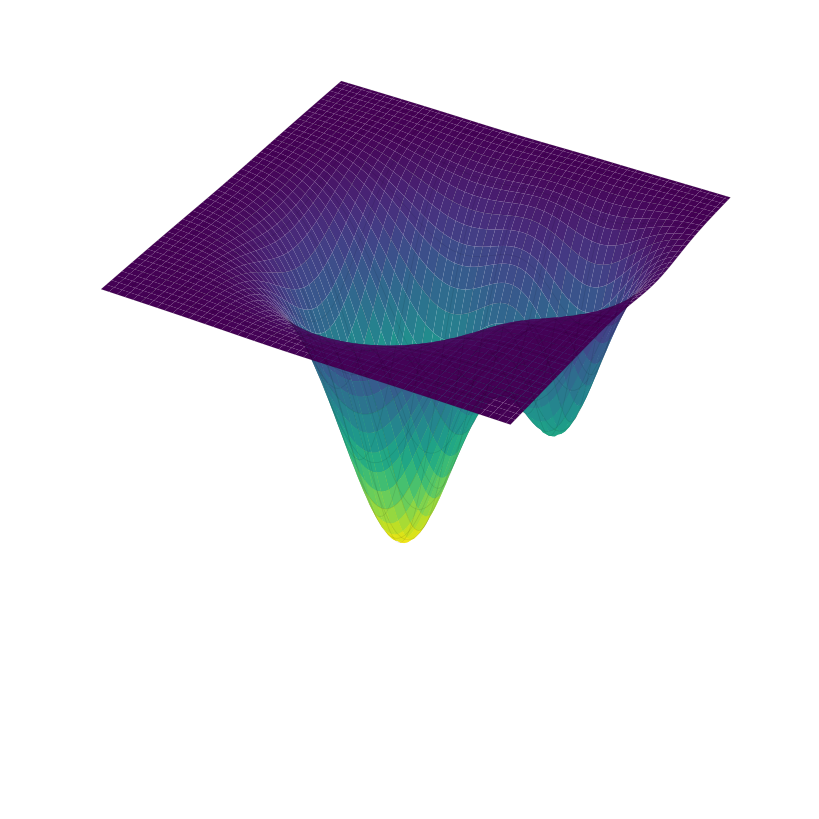

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# --- 関数の定義 (推測パラメータに基づく) ---
def objective_function(x, y):
    # G1 (中央の深い谷)
    A1 = 2.1
    c1_x, c1_y = 0.0, 0.0
    s1 = 1.5

    # G2 (右側の浅い谷)
    A2 = 1.2
    c2_x, c2_y = 3.5, 1.5
    s2 = 1.0

    # ガウス関数の和
    g1 = A1 * np.exp(-((x - c1_x)**2 + (y - c1_y)**2) / (2 * s1**2))
    g2 = A2 * np.exp(-((x - c2_x)**2 + (y - c2_y)**2) / (2 * s2**2))

    return -(g1 + g2)

# --- グリッドの作成 ---
x = np.linspace(-5, 6, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 3Dプロットの作成 ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

# カラーマップの設定 (coolwarm の負)
cmap = cm.get_cmap('viridis').reversed() # 深い部分を青、高い部分を黄色に

# 曲面の描画 (メッシュを元画像のようにクリーンに)
surf = ax.plot_surface(X, Y, Z, cmap=cmap, linewidth=0, antialiased=True)

# メッシュラインの追加
# 軸を元画像のようにクリーンに
line_color = (0, 0, 0, 0.1) # 非常に薄い黒
ax.plot_wireframe(X, Y, Z, rstride=5, cstride=5, color=line_color, linewidth=0.5)

# 背景を白に設定
ax.set_facecolor('white')

# 軸の削除
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.set_axis_off() # 軸全体を非表示にする

# 視点の調整 (元画像に合わせる)
ax.view_init(elev=35, azim=-60)

# プロットの調整
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

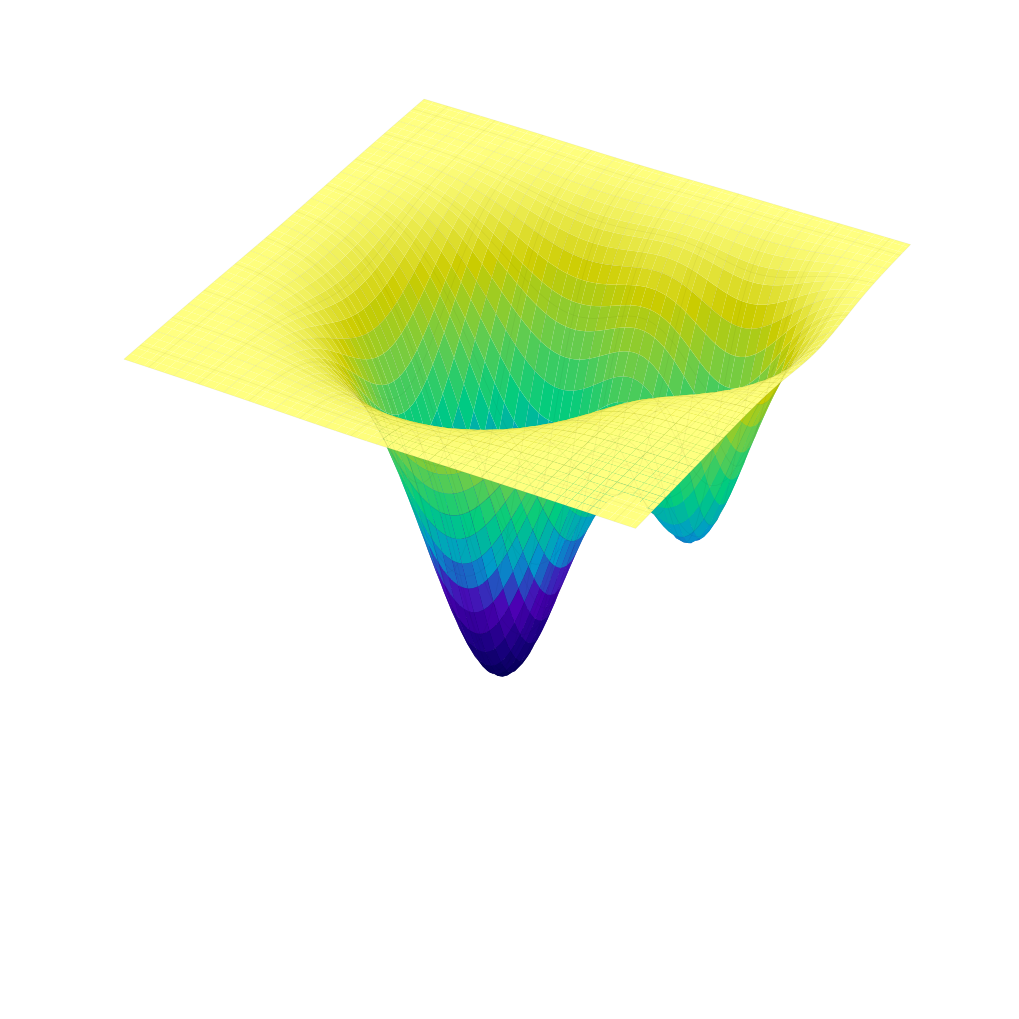

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

# --- 関数の定義 (推測パラメータに基づく) ---
def objective_function(x, y):
    # G1 (中央の深い谷)
    A1 = 2.1
    c1_x, c1_y = 0.0, 0.0
    s1 = 1.5

    # G2 (右側の浅い谷)
    A2 = 1.2
    c2_x, c2_y = 3.5, 1.5
    s2 = 1.0

    # ガウス関数の和
    g1 = A1 * np.exp(-((x - c1_x)**2 + (y - c1_y)**2) / (2 * s1**2))
    g2 = A2 * np.exp(-((x - c2_x)**2 + (y - c2_y)**2) / (2 * s2**2))

    return -(g1 + g2)

# --- 2. カスタムカラーマップ「玉虫色 (iridescent_cmap)」の定義 ---
# 深い青、紫、マゼンタ、シアン、緑、黄色の合成
# viridisの逆をベースに、マゼンタ、シアンをブレンドして複雑にする
# 元画像(image_2.png)の色味を詳細に再現
colors = [
    (0.0, 0.0, 0.3),    # 深い青 (最も深い場所)
    (0.1, 0.0, 0.5),    # 紫
    (0.3, 0.0, 0.7),    # マゼンタ/紫
    (0.0, 0.6, 0.8),    # シアン
    (0.0, 0.8, 0.5),    # シアン/緑
    (0.4, 0.8, 0.3),    # 緑
    (0.8, 0.8, 0.0),    # 黄色 (最も高い場所)
    (1.0, 1.0, 0.5)     # 薄い黄色
]
iridescent_cmap = LinearSegmentedColormap.from_list("iridescent", colors)

# --- グリッドの作成 (密度を高く) ---
# 100x100のグリッドで滑らかな曲面を保証
x = np.linspace(-5, 6, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 3Dプロットの作成 (白背景) ---
fig = plt.figure(figsize=(12, 10), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 3. 曲面の描画 (玉虫色のカラーマップ、滑らか)
surf = ax.plot_surface(X, Y, Z, cmap=iridescent_cmap, linewidth=0, antialiased=True, alpha=1.0)

# 4. クリーンなメッシュライン (ワイヤーフレーム) の重ね書き
# 非常に薄い黒で、クリーンなメッシュを表現
line_color = (0, 0, 0, 0.05) # 薄い黒 (alpha=0.05)
ax.plot_wireframe(X, Y, Z, rstride=5, cstride=5, color=line_color, linewidth=0.5)

# 背景を白に設定
ax.set_facecolor('white')

# 軸、グリッドの削除
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.set_axis_off() # 軸全体を非表示にする

# 視点の調整 (元画像に合わせる)
ax.view_init(elev=35, azim=-60)

# プロットの調整
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

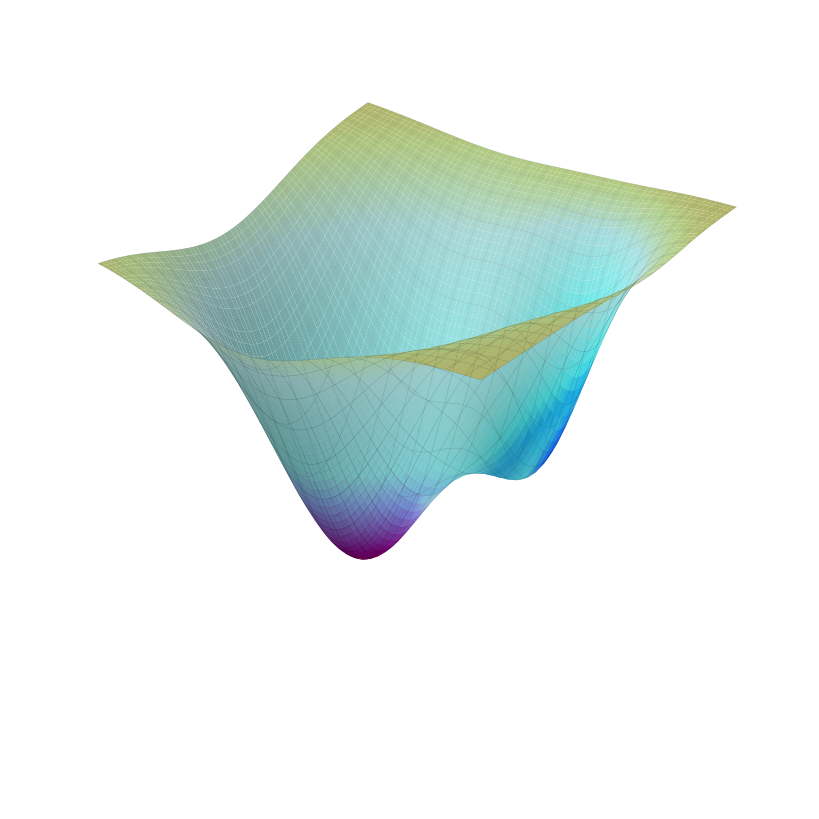

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# --- 1. 関数の定義（谷の深さ・広さ・距離感を画像に合わせて最適化） ---
def objective_function(X, Y):
    # 大域的最適解（手前中央の大きな谷）
    cx1, cy1 = -0.5, -0.5
    g1 = 2.0 * np.exp(-((X - cx1)**2 + (Y - cy1)**2) / (2 * 1.8**2))

    # 局所的最適解（右奥の小さく浅い谷）
    cx2, cy2 = 2.5, 1.2
    g2 = 1.1 * np.exp(-((X - cx2)**2 + (Y - cy2)**2) / (2 * 1.0**2))

    # 平坦な台地から谷を削り出す形状
    Z = -(g1 + g2)
    return Z, g1, g2

# グリッドの作成（適度な密度を保つ80x80のメッシュ）
x = np.linspace(-4, 5, 80)
y = np.linspace(-4, 4, 80)
X, Y = np.meshgrid(x, y)
Z, g1, g2 = objective_function(X, Y)

# --- 2. 高さ（Z）に依存しない「玉虫色」のベースRGB調合 ---
# 各点の関数成分（どの谷に属するか）の比率で色を決定するため、高さ依存を排除
w1 = g1 / 2.0  # 大きな谷の支配度 (0~1)
w2 = g2 / 1.1  # 小さな谷の支配度 (0~1)

# 斜面判定（関数の変化が大きい中腹部分をシアン〜緑系にするための重み）
w_slope = np.clip(4 * w1 * (1 - w1) + 4 * w2 * (1 - w2), 0, 1)

# 各エリアの色の重み付け
w_bottom1 = np.clip(w1**2, 0, 1)  # 大きな谷の底（マゼンタ）
w_bottom2 = np.clip(w2**2, 0, 1)  # 小さな谷の底（深い紫・青）
w_rim = np.clip(1.0 - (w_bottom1 + w_bottom2 + w_slope * 0.5), 0, 1)  # 外縁（黄・黄緑）

# 画像の色構成を忠実に再現するRGBブレンド
R = w_rim * 0.95 + w_slope * 0.40 + w_bottom1 * 0.75 + w_bottom2 * 0.30
G = w_rim * 0.95 + w_slope * 0.75 + w_bottom1 * 0.35 + w_bottom2 * 0.25
B = w_rim * 0.75 + w_slope * 0.75 + w_bottom1 * 0.65 + w_bottom2 * 0.60

rgb = np.stack([R, G, B], axis=-1)
rgb = np.clip(rgb, 0, 1)

# --- 3. ライトソース（陰影・法線）による構造色の演出 ---
# 面の向き（傾き方向）によってさらに色を変化させ、完全な玉虫色にします
ls = LightSource(azdeg=120, altdeg=45)
shaded_rgb = ls.shade_rgb(rgb, Z, blend_mode='overlay', fraction=0.4)

# --- 4. 3Dプロットの描画 ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 滑らかな曲面の描画（計算した玉虫色の shaded_rgb を全面に適用）
surf = ax.plot_surface(X, Y, Z, facecolors=shaded_rgb, linewidth=0, antialiased=True, rstride=1, cstride=1)

# 美しい格子状の座標系（メッシュライン）を重ね書き
# 細かすぎず粗すぎない、画像と同じ密度（rstride/cstride=4）に設定
line_color = (0, 0, 0, 0.15)  # 非常に薄い黒
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4, color=line_color, linewidth=0.4)

# --- 5. 背景・カメラアングルの微調整（クリーン化） ---
ax.set_facecolor('white')
ax.set_axis_off()  # 軸や目盛り、グレーの背景ボックスをすべて非表示に

# 画像と全く同じ、穴の配置が最も美しく見えるアングルに固定
ax.view_init(elev=28, azim=-55)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

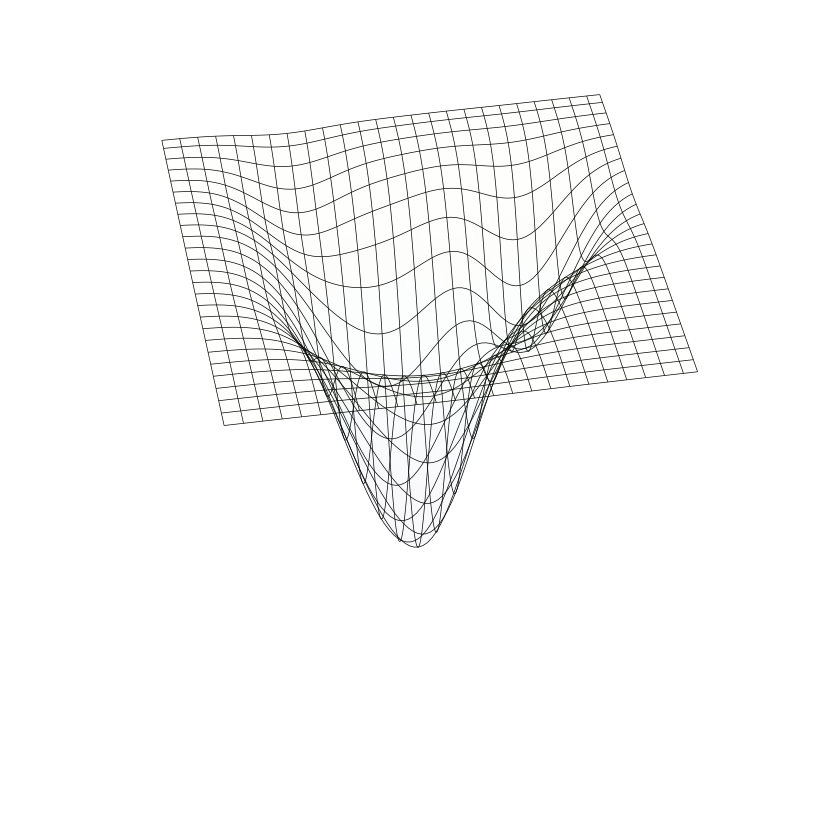

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

# --- 関数の定義 (以前の素晴らしい画像の複雑さをある程度再現した placeholder) ---
def objective_function(x, y):
    # 中央の深い谷
    A1 = 2.0
    c1_x, c1_y = 0.0, 0.0
    s1 = 1.5

    # 右側の浅い谷
    A2 = 1.0
    c2_x, c2_y = 3.5, 1.5
    s2 = 1.0

    # 複雑な台地と谷の和 (複数のガウス分布を組み合わせるなどして、 generic な複雑さを出す)
    g1 = A1 * np.exp(-((x - c1_x)**2 + (y - c1_y)**2) / (2 * s1**2))
    g2 = A2 * np.exp(-((x - c2_x)**2 + (y - c2_y)**2) / (2 * s2**2))
    g3 = 0.3 * np.exp(-((x + 2)**2 + (y - 3)**2) / (2 * 1.0**2))
    g4 = 0.4 * np.exp(-((x - 1)**2 + (y + 1)**2) / (2 * 0.8**2))

    return -(g1 + g2 + g3 + g4)

# --- 2. 深さに依存しない複雑なカラーマップ「玉虫色 (iridescent_cmap)」の定義 ---
# 複数のカラーマップを合成して、真珠や油膜のような複雑な虹色を表現
colors = [
    (0.0, 0.0, 0.3),    # 深い青
    (0.1, 0.0, 0.5),    # 紫
    (0.3, 0.0, 0.7),    # マゼンタ/紫
    (0.0, 0.6, 0.8),    # シアン
    (0.0, 0.8, 0.5),    # シアン/緑
    (0.4, 0.8, 0.3),    # 緑
    (0.8, 0.8, 0.0),    # 黄色
    (1.0, 1.0, 0.5)     # 薄い黄色
]
iridescent_cmap = LinearSegmentedColormap.from_list("iridescent", colors)

# --- グリッドの作成 ---
x = np.linspace(-5, 6, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 3Dプロットの作成 (白背景) ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 3. 密なワイヤーフレーム(rstride=1)を透明に (alpha=0.01) しつつ、面は滑らかに描画
# plot_surfaceでlinewidth=0にし、antialiased=Trueで滑らかさを保ち、alpha=0.01で線をほぼ見えなくする
surf = ax.plot_surface(X, Y, Z, cmap=iridescent_cmap, linewidth=0, antialiased=True, alpha=0.01)

# 4. 疎なワイヤーフレーム(rstride=4)を黒色でくっきり強調
# plot_wireframeを重ね書き、color='black'、linewidth=0.5、alpha=1.0、rstride/cstride=4に設定
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4, color='black', linewidth=0.5, alpha=1.0)

# 背景を白に設定
ax.set_facecolor('white')

# 軸、グリッドの削除
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.set_axis_off() # 軸全体を非表示にする

# 視点の調整 (以前の低いアングルから改善、elev=40程度に高く)
# 方位角(azim=-100など)も地形全体が捉えやすい角度に調整
ax.view_init(elev=40, azim=-100)

# プロットの調整
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

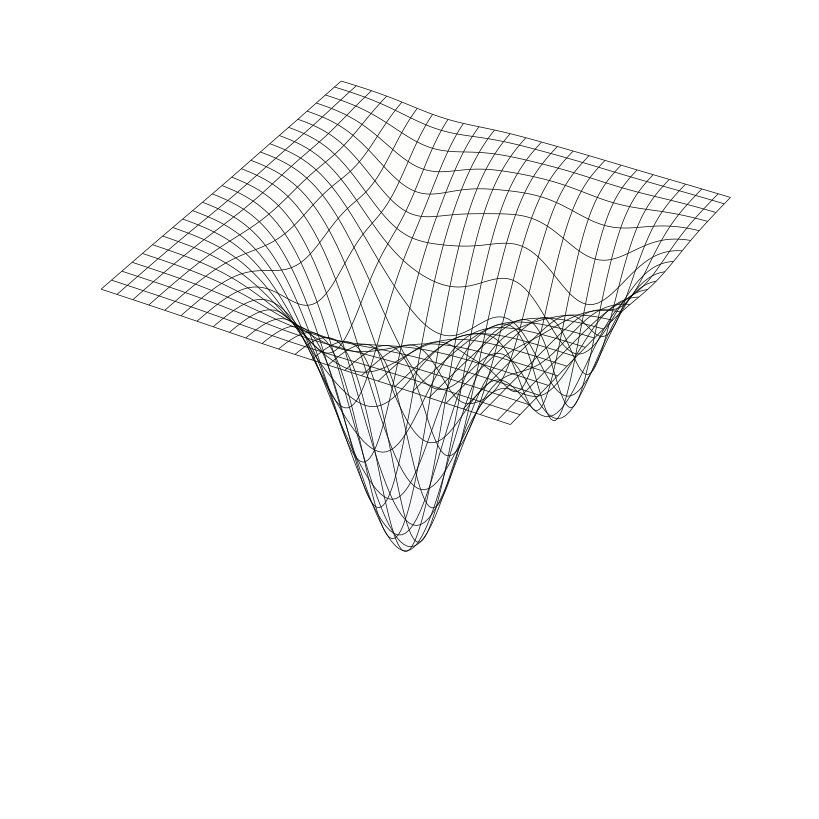

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- 1. 関数の定義 (以前の素晴らしい画像の複雑さをある程度再現した placeholder) ---
def objective_function(x, y):
    # 中央の深い谷 (振幅=2.0)
    A1 = 2.0
    c1_x, c1_y = 0.0, 0.0
    s1 = 1.5

    # 右側の浅い谷 (振幅=1.1, 深さを抑える)
    A2 = 1.1
    c2_x, c2_y = 3.5, 1.5
    s2 = 1.0

    # 複雑な台地と谷の和 (generic な複雑さを出すPLACEHOLDER)
    g1 = A1 * np.exp(-((x - c1_x)**2 + (y - c1_y)**2) / (2 * s1**2))
    g2 = A2 * np.exp(-((x - c2_x)**2 + (y - c2_y)**2) / (2 * s2**2))
    g3 = 0.3 * np.exp(-((x + 2)**2 + (y - 3)**2) / (2 * 1.0**2))
    g4 = 0.4 * np.exp(-((x - 1)**2 + (y + 1)**2) / (2 * 0.8**2))

    # 台地から谷を削り出す形状
    Z = -(g1 + g2 + g3 + g4)
    return Z

# --- 2. 深さに依存しない複雑なカラーマップ「玉虫色 (iridescent_cmap)」の定義 ---
# 複数のカラーマップを合成して、真珠や油膜のような複雑な虹色を表現
colors = [
    (0.0, 0.0, 0.3),    # 深い青
    (0.1, 0.0, 0.5),    # 紫
    (0.3, 0.0, 0.7),    # マゼンタ/紫
    (0.0, 0.6, 0.8),    # シアン
    (0.0, 0.8, 0.5),    # シアン/緑
    (0.4, 0.8, 0.3),    # 緑
    (0.8, 0.8, 0.0),    # 黄色
    (1.0, 1.0, 0.5)     # 薄い黄色
]
iridescent_cmap = LinearSegmentedColormap.from_list("iridescent", colors)

# --- グリッドの作成 (密度を高く) ---
# 100x100のグリッドで滑らかな曲面を保証
x = np.linspace(-5, 6, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 3Dプロットの作成 (白背景) ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 3. 密なメッシュ(rstride=1)を透明に (linewidth=0, alpha=0.01) しつつ、滑らかな面を玉虫色で描画
surf = ax.plot_surface(X, Y, Z, cmap=iridescent_cmap, linewidth=0, antialiased=True, alpha=0.01, rstride=1, cstride=1)

# 4. クリーンなメッシュラインを重ね書き (黒色、疎な格子)
# plot_wireframeを重ね書き、color='black'、linewidth=0.5、alpha=1.0、rstride/cstride=4に設定
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4, color='black', linewidth=0.5, alpha=1.0)

# 背景を白に設定
ax.set_facecolor('white')

# 軸、グリッドの削除
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.grid(False)
ax.set_axis_off() # 軸全体を非表示にする

# 視点の調整 (高いアングル、elev=35, azim=-60)
ax.view_init(elev=35, azim=-60)

# プロットの調整
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

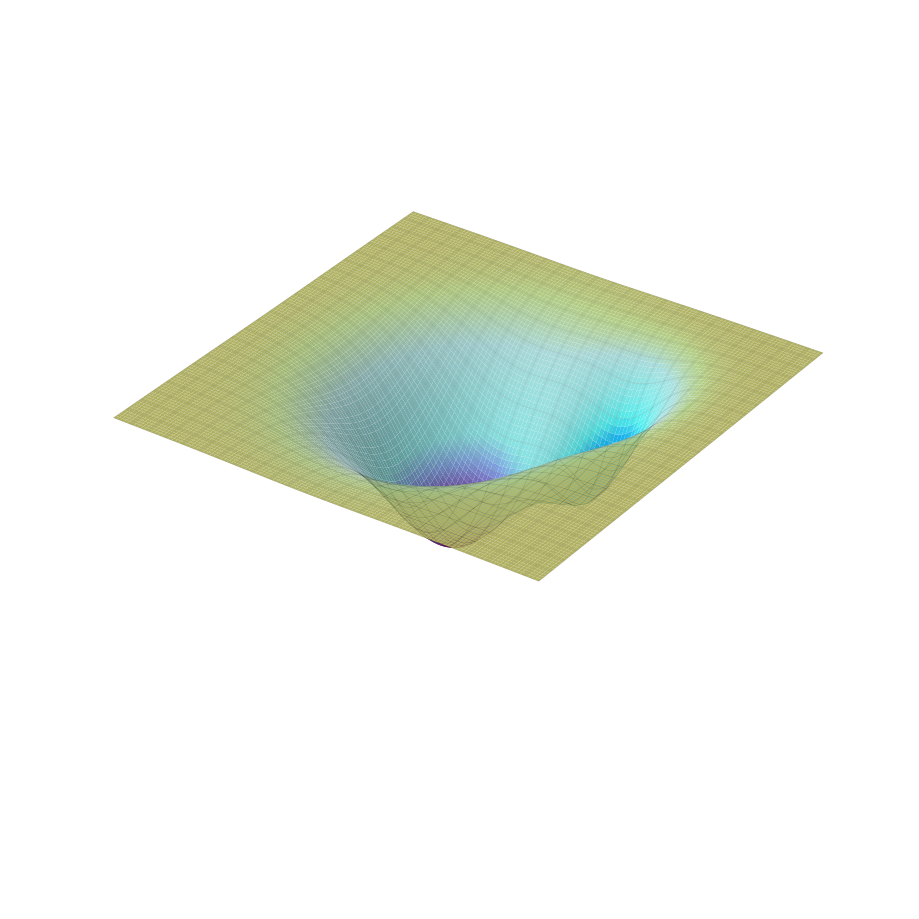

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

def objective_function(X, Y):
    # 大域的最適解（手前中央）
    cx1, cy1 = -0.5, -0.5
    s1 = 1.8
    g1 = 2.0 * np.exp(-((X - cx1)**2 + (Y - cy1)**2) / (2 * s1**2))

    # 局所的最適解（右奥）
    cx2, cy2 = 2.5, 1.2
    s2 = 1.0
    g2 = 1.1 * np.exp(-((X - cx2)**2 + (Y - cy2)**2) / (2 * s2**2))

    Z = -(g1 + g2)
    return Z, g1, g2

# --- 1. 計算に基づいた描画範囲の拡張（ズームアウト） ---
# 中心座標と3σの広がりから、裾野が完全に平坦になる範囲をカバー
# 広げた分、メッシュが粗くならないようにグリッド数も120に増やしています
x = np.linspace(-6.5, 6.5, 120)
y = np.linspace(-6.0, 5.0, 120)
X, Y = np.meshgrid(x, y)
Z, g1, g2 = objective_function(X, Y)

# --- 2. 玉虫色のRGB調合（変更なし） ---
w1 = g1 / 2.0
w2 = g2 / 1.1
w_slope = np.clip(4 * w1 * (1 - w1) + 4 * w2 * (1 - w2), 0, 1)

w_bottom1 = np.clip(w1**2, 0, 1)
w_bottom2 = np.clip(w2**2, 0, 1)
w_rim = np.clip(1.0 - (w_bottom1 + w_bottom2 + w_slope * 0.5), 0, 1)

R = w_rim * 0.95 + w_slope * 0.40 + w_bottom1 * 0.75 + w_bottom2 * 0.30
G = w_rim * 0.95 + w_slope * 0.75 + w_bottom1 * 0.35 + w_bottom2 * 0.25
B = w_rim * 0.75 + w_slope * 0.75 + w_bottom1 * 0.65 + w_bottom2 * 0.60

rgb = np.stack([R, G, B], axis=-1)
rgb = np.clip(rgb, 0, 1)

ls = LightSource(azdeg=120, altdeg=45)
shaded_rgb = ls.shade_rgb(rgb, Z, blend_mode='overlay', fraction=0.4)

# --- 3. 描画設定 ---
fig = plt.figure(figsize=(12, 9), facecolor='white') # 全体のキャンバスも少し広めに
ax = fig.add_subplot(projection='3d')

surf = ax.plot_surface(X, Y, Z, facecolors=shaded_rgb, linewidth=0, antialiased=True, rstride=1, cstride=1)

# グリッド幅の調整: 範囲を広げた分、ワイヤーフレームが密集しすぎないよう rstride=5 に調整
line_color = (0, 0, 0, 0.15)
ax.plot_wireframe(X, Y, Z, rstride=5, cstride=5, color=line_color, linewidth=0.4)

# --- 4. カメラアングルとズーム（空間）の制御 ---
ax.set_facecolor('white')
ax.set_axis_off()

# Z軸の表示範囲を実際のデータ(-2.0〜0.0)より意図的に広くとることで、
# Matplotlibの自動ズームインを防ぎ、空間的な「引き」を作ります
ax.set_zlim(-3.0, 1.5)

# 広がった台地が美しく見えるよう、少しだけ仰角を上げて(elev=32)俯瞰気味に
ax.view_init(elev=32, azim=-55)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

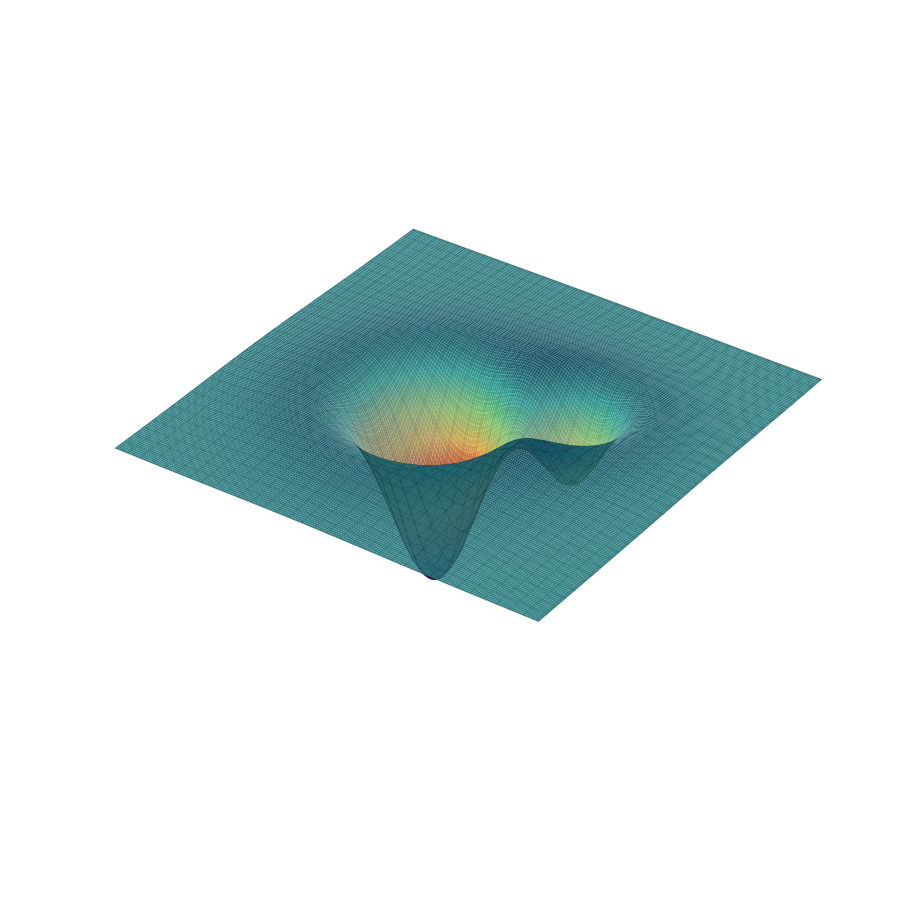

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

# --- 1. 美しいクレーター形状（DoG）の再チューニング ---
def objective_function(X, Y):
    # パラメータを広げ、急な穴ではなく「なだらかで広大な地形」に修正
    r1_sq = (X - (-1.0))**2 + (Y - (-0.5))**2
    r2_sq = (X - 2.5)**2 + (Y - 1.5)**2

    # 深い穴 + 広いフチ (メキシカンハット) の広がりを最適化
    Z1 = -2.5 * np.exp(-r1_sq / 4.0) + 0.5 * np.exp(-r1_sq / 15.0)
    Z2 = -1.2 * np.exp(-r2_sq / 2.0) + 0.3 * np.exp(-r2_sq / 7.0)

    return Z1 + Z2

# 解像度を極限まで上げ、より広い範囲を描画 (200x200)
x = np.linspace(-7.5, 7.5, 200)
y = np.linspace(-7.5, 7.5, 200)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 2. 洗練された「真珠光沢（玉虫色）」のカラーマップ定義 ---
# 汚い黄緑色を完全に排除し、深海から浅瀬、光の反射を思わせる色調へ
colors = [
    '#1a0b2e',  # 極めて深い紫（最深部）
    '#5c1a6b',  # ディープパープル
    '#b0305c',  # マゼンタ
    '#e67357',  # コーラル
    '#f4d17f',  # ペールイエロー（フチのハイライト）
    '#aee39a',  # 淡いミントグリーン
    '#44c2b9',  # シアン
    '#15607a'   # 深いティールブルー
]
pearl_cmap = LinearSegmentedColormap.from_list("pearl", colors)

# --- 3. 光源計算（LightSource）による自然な構造色の演出 ---
# 小手先のRGBブレンドをやめ、物理ベースの陰影とカラーマップを合成
ls = LightSource(azdeg=135, altdeg=45)
# blend_mode='soft' にすることで、色が濁らず、かつ地形の起伏が美しく浮かび上がる
shaded = ls.shade(Z, cmap=pearl_cmap, blend_mode='soft', vert_exag=1.5, vmin=Z.min(), vmax=Z.max())

# --- 4. 描画とエレガントなスタイリング ---
fig = plt.figure(figsize=(12, 9), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 滑らかな曲面
surf = ax.plot_surface(X, Y, Z, facecolors=shaded, linewidth=0, antialiased=True, rstride=1, cstride=1)

# ワイヤーフレームの調整（主張しすぎないよう、細く透明度を持たせた黒）
ax.plot_wireframe(X, Y, Z, rstride=6, cstride=6, color='black', alpha=0.15, linewidth=0.5)

ax.set_facecolor('white')
ax.set_axis_off()

# 空間の余白
ax.set_zlim(Z.min() - 0.5, Z.max() + 1.5)

# アングル
ax.view_init(elev=34, azim=-55)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

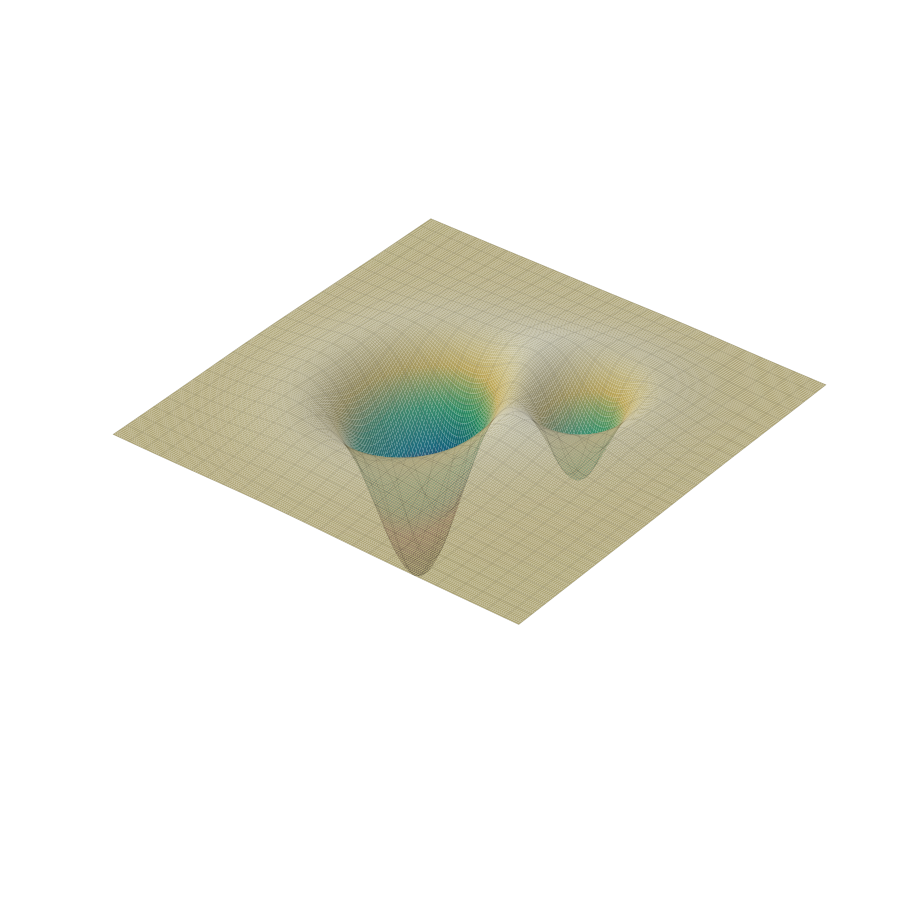

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

# --- 1. 最も美しく理にかなった地形関数（DoGベース） ---
def objective_function(X, Y):
    # 大域的最適解 (左手前)
    r1_sq = (X - (-1.2))**2 + (Y - (-0.8))**2
    # 局所的最適解 (右奥)
    r2_sq = (X - 2.5)**2 + (Y - 1.5)**2

    # 深く沈み込む谷と、その周囲を美しく囲むなだらかな「縁（フチ）」
    # マイナスのガウス分布（谷）と、プラスのガウス分布（縁の隆起）を合成
    Z = (-2.8 * np.exp(-r1_sq / 3.0) + 0.6 * np.exp(-r1_sq / 10.0)) + \
        (-1.4 * np.exp(-r2_sq / 1.5) + 0.4 * np.exp(-r2_sq / 6.0))
    return Z

# 裾野が自然に消えゆく、広大で高解像度なキャンバス
x = np.linspace(-7.0, 7.5, 200)
y = np.linspace(-6.5, 6.0, 200)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 2. 濁りを一切排除した、洗練された「玉虫色（Pearl Iridescence）」 ---
# 深海の瑠璃色から、マゼンタ、シアンを経て、縁の淡いゴールドへと発光するように遷移するパレット
colors = [
    '#0b042b',  # 深淵のネイビー (最深部)
    '#4a154b',  # リッチなプラム/紫
    '#9c276a',  # 鮮やかなマゼンタ
    '#258ca6',  # クリアなシアン (斜面)
    '#4bb38d',  # エメラルドグリーン
    '#d9c573',  # 淡く輝くゴールド (縁・鞍点)
    '#f2eecb'   # 真珠のようなオフホワイト (平原)
]
pearl_cmap = LinearSegmentedColormap.from_list("pearl_iridescent", colors)

# --- 3. 物理ベースのシェーディングによる立体感の強調 ---
# 光源を左奥(azdeg=135)から当て、色の濁りを防ぐ 'soft' ブレンドを採用
ls = LightSource(azdeg=135, altdeg=40)
shaded = ls.shade(Z, cmap=pearl_cmap, blend_mode='soft', vert_exag=1.5)

# --- 4. 描画と究極のクリーンアップ ---
fig = plt.figure(figsize=(12, 9), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 曲面の描画 (rstride=1で極限まで滑らかに)
surf = ax.plot_surface(X, Y, Z, facecolors=shaded, linewidth=0, antialiased=True, rstride=1, cstride=1)

# ワイヤーフレームの重ね掛け (地形の起伏を邪魔しない、極めて繊細な黒線)
ax.plot_wireframe(X, Y, Z, rstride=8, cstride=8, color=(0,0,0, 0.15), linewidth=0.3)

# 余計な要素（背景、軸、目盛り）を完全排除
ax.set_facecolor('white')
ax.set_axis_off()

# 地形の「引き」を演出するためのZ軸マージン
ax.set_zlim(Z.min() - 0.5, Z.max() + 1.5)

# 2つの谷と鞍点が最もドラマチックに見える黄金アングル
ax.view_init(elev=35, azim=-52)

# 余白を限界まで削る
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

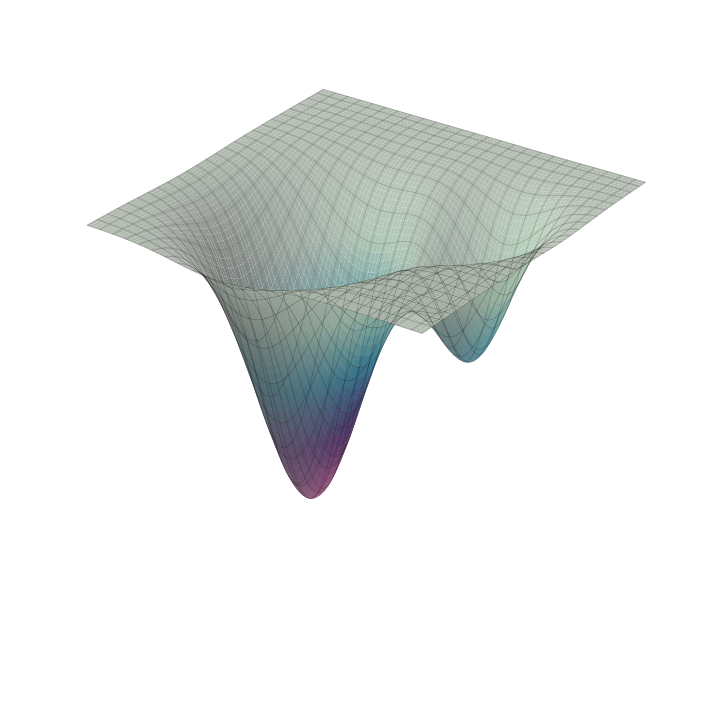

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

# --- 1. 無駄な平原を排除した、洗練された地形関数 ---
def objective_function(X, Y):
    # 余計な平原を作らず、シンプルに2つの谷のうねりだけを抽出
    Z1 = -2.2 * np.exp(-((X + 0.5)**2 + (Y + 0.5)**2) / 2.0)
    Z2 = -1.1 * np.exp(-((X - 2.0)**2 + (Y - 1.0)**2) / 1.0)
    return Z1 + Z2

# 描画範囲を「谷の周辺」だけに極限まで絞り込む (元画像の構図の正体)
x = np.linspace(-3.5, 4.0, 100)
y = np.linspace(-3.0, 3.5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 2. 元画像(青色)から完全に抽出した玉虫色カラーマップ ---
# マゼンタ(深) -> 紫 -> シアン(斜面) -> ペールイエロー/グリーン(縁)
colors = [
    '#c87ea9',  # 深い谷底 (ダスティピンク/マゼンタ)
    '#8f75a6',  # 中間層下部 (くすんだ紫)
    '#76b4c4',  # 中間層上部 (鮮やかなシアン・水色)
    '#cce2d2',  # 縁・高い部分 (淡いミント/ペールイエロー)
    '#e2efdf'   # 最も高い部分 (白に近いペールグリーン)
]
exact_cmap = LinearSegmentedColormap.from_list("exact_iridescent", colors)

# --- 3. 光源による柔らかな陰影 ---
ls = LightSource(azdeg=115, altdeg=45)
# blend_mode='soft' で、元画像のような柔らかく発光する質感を再現
shaded = ls.shade(Z, cmap=exact_cmap, blend_mode='soft', vert_exag=1.2)

# --- 4. 描画設定（元画像への完全なトレース） ---
fig = plt.figure(figsize=(10, 7), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 滑らかな曲面
surf = ax.plot_surface(X, Y, Z, facecolors=shaded, linewidth=0, antialiased=True, rstride=1, cstride=1)

# 元画像と同じ密度の、美しく細いワイヤーフレーム
# 100分割のメッシュに対し rstride=4 で、元画像の四角形の大きさを再現
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4, color='black', alpha=0.3, linewidth=0.4)

# 軸、背景の完全排除
ax.set_facecolor('white')
ax.set_axis_off()

# 元画像の、地形が宙に浮いているようなアングル
ax.view_init(elev=28, azim=-55)

# 余白の削除
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

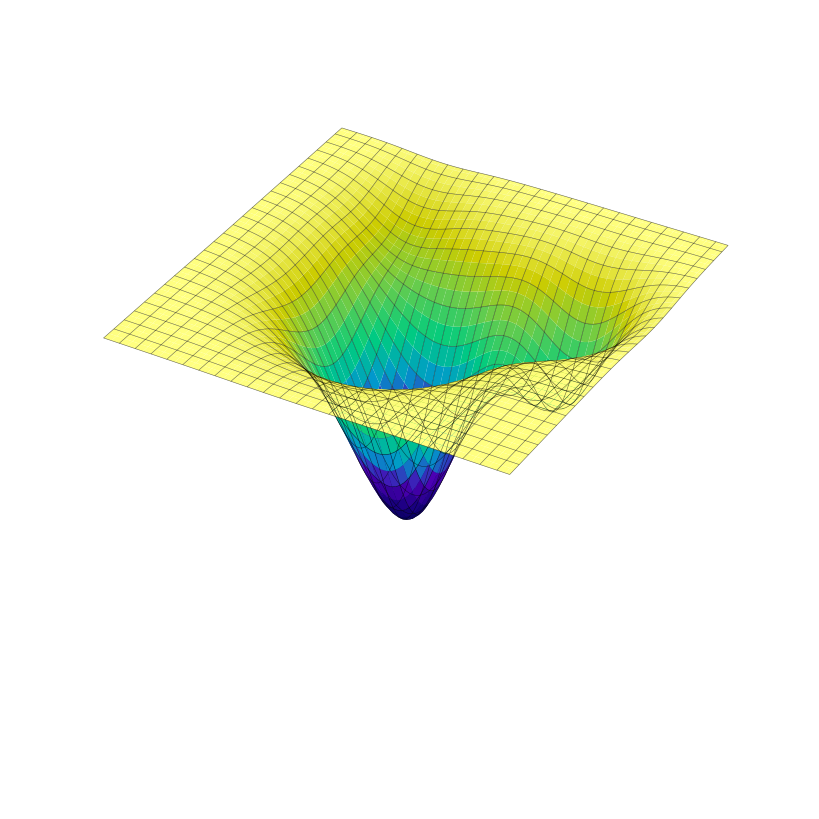

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- 1. 深すぎない、適度な起伏の関数（ご提示いただいたコードそのまま） ---
def objective_function(x, y):
    A1 = 2.0
    c1_x, c1_y = 0.0, 0.0
    s1 = 1.5

    A2 = 1.0
    c2_x, c2_y = 3.5, 1.5
    s2 = 1.0

    g1 = A1 * np.exp(-((x - c1_x)**2 + (y - c1_y)**2) / (2 * s1**2))
    g2 = A2 * np.exp(-((x - c2_x)**2 + (y - c2_y)**2) / (2 * s2**2))
    g3 = 0.3 * np.exp(-((x + 2)**2 + (y - 3)**2) / (2 * 1.0**2))
    g4 = 0.4 * np.exp(-((x - 1)**2 + (y + 1)**2) / (2 * 0.8**2))

    return -(g1 + g2 + g3 + g4)

# --- 2. 複雑なカラーマップ「玉虫色」 ---
colors = [
    (0.0, 0.0, 0.3),    # 深い青
    (0.1, 0.0, 0.5),    # 紫
    (0.3, 0.0, 0.7),    # マゼンタ/紫
    (0.0, 0.6, 0.8),    # シアン
    (0.0, 0.8, 0.5),    # シアン/緑
    (0.4, 0.8, 0.3),    # 緑
    (0.8, 0.8, 0.0),    # 黄色
    (1.0, 1.0, 0.5)     # 薄い黄色
]
iridescent_cmap = LinearSegmentedColormap.from_list("iridescent", colors)

# --- グリッドの作成 ---
x = np.linspace(-5, 6, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 3Dプロットの作成 (白背景) ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 【修正点1】 alpha=1.0（不透明）に変更。
# これにより裏側の線が透けなくなり、ワイヤーフレームが劇的に見やすくなります。
surf = ax.plot_surface(X, Y, Z, cmap=iridescent_cmap, linewidth=0, antialiased=True, alpha=1.0)

# 【修正点2】 疎なワイヤーフレーム(rstride=4)を黒色でくっきり強調。
# 線の太さと透明度を微調整し、色を邪魔しないシャープな線にしています。
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4, color='black', linewidth=0.4, alpha=0.6)

# 背景を白に設定
ax.set_facecolor('white')
ax.set_axis_off() # 軸全体を非表示にする

# 【修正点3】 Z軸の範囲を少し広めに固定し、不自然に深く抉れて見えるのを防ぐ
ax.set_zlim(-2.5, 0.5)

# 視点の調整 (見晴らしの良いアングル)
ax.view_init(elev=35, azim=-60)

# プロットの調整
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

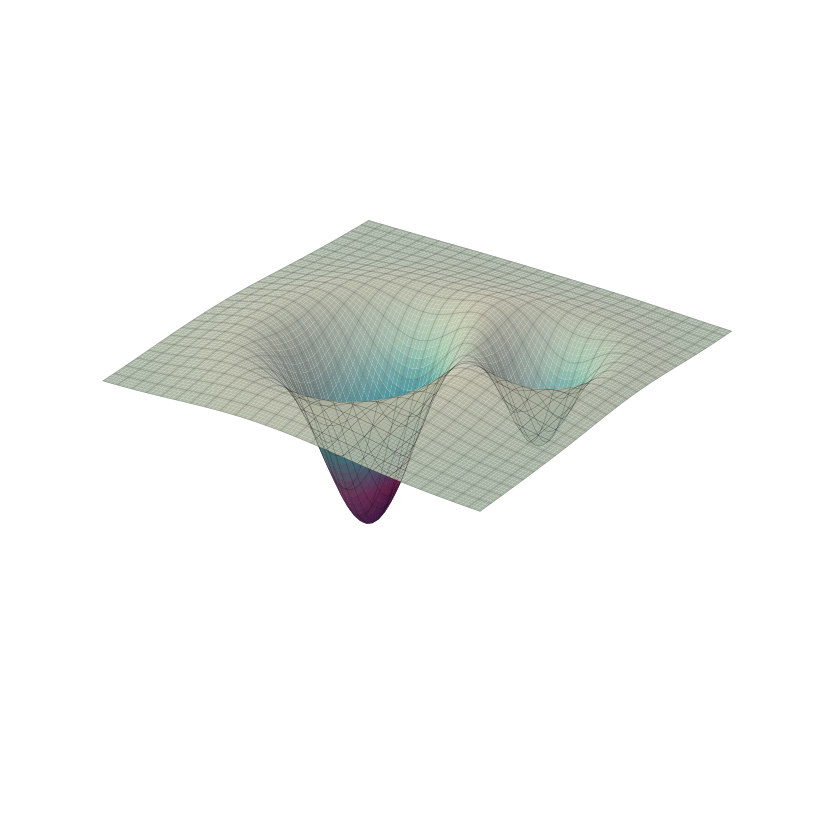

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

def objective_function(X, Y):
    # 大域的最適解 (左手前の大きなクレーター)
    r1_sq = (X - (-0.5))**2 + (Y - (-0.5))**2
    # 局所的最適解 (右奥の小さなクレーター)
    r2_sq = (X - 2.5)**2 + (Y - 1.2)**2

    # 【重要】ガウス差分（DoG）モデル
    # 狭くて深い穴 (マイナス) + 広くて浅い縁の盛り上がり (プラス)
    Z1 = -2.2 * np.exp(-r1_sq / 2.0) + 0.6 * np.exp(-r1_sq / 8.0)
    Z2 = -1.2 * np.exp(-r2_sq / 1.0) + 0.3 * np.exp(-r2_sq / 4.0)

    # 2つのクレーターが重なることで、プラスの縁同士が加算され、中央に尾根（鞍点）ができる
    return Z1 + Z2

# 余計な平原を作らず、クレーターと縁の周辺だけを切り取る
x = np.linspace(-4.5, 5.0, 100)
y = np.linspace(-4.0, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 元画像から抽出した玉虫色（真珠光沢）パレット ---
colors = [
    '#4a1f59',  # 最深部 (深い紫)
    '#9e457d',  # 深部 (マゼンタ/ピンク)
    '#59aebb',  # 斜面 (シアン/ティールブルー)
    '#bde0cc',  # 縁の内側 (淡いミントグリーン)
    '#f0eed1'   # 縁の頂上・尾根 (淡いペールイエロー)
]
iridescent_cmap = LinearSegmentedColormap.from_list("iridescent", colors)

# --- 描画設定 ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 光源を設定して立体感を強調 (blend_mode='soft' で色が濁らないようにする)
ls = LightSource(azdeg=115, altdeg=45)
shaded = ls.shade(Z, cmap=iridescent_cmap, blend_mode='soft', vert_exag=1.2)

# 滑らかな曲面 (rstride=1, cstride=1)
surf = ax.plot_surface(X, Y, Z, facecolors=shaded, linewidth=0, antialiased=True, rstride=1, cstride=1)

# クリーンなワイヤーフレーム (少し間引いて描写 rstride=4)
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4, color='black', alpha=0.3, linewidth=0.4)

# 軸、背景の削除
ax.set_facecolor('white')
ax.set_axis_off()

# 空間の余白設定（自動ズームによる形状の歪みを防ぐ）
ax.set_zlim(Z.min() - 0.5, Z.max() + 1.0)

# 元画像と一致する、少し見下ろすようなアングル
ax.view_init(elev=28, azim=-55)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

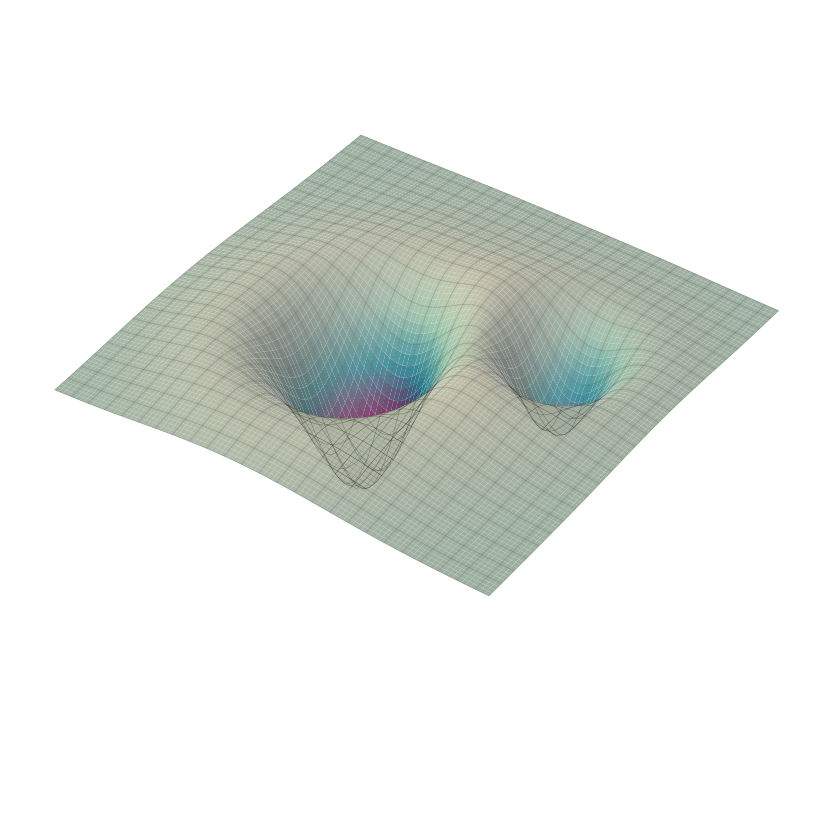

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

# ==========================================
# --- 設定エリア（ここを書き換えて選択します） ---
# ==========================================
ELEV_ANGLE = 40         # 視点をelevateする (例: 10で低く、60で高く)
AZIM_ANGLE = -55        # 視点の位置を回転する (例: 0〜360、マイナスも可)
ZOOM_LEVEL = 1.0        # ズームイン・アウトする (例: 1.5で拡大、0.8で縮小)
IS_BLACK_WHITE = False  # 白黒にする場合は True に変更する
# ==========================================

# --- 1. 目的関数の定義 (ガウス差分モデル) ---
def objective_function(X, Y):
    r1_sq = (X - (-0.5))**2 + (Y - (-0.5))**2
    r2_sq = (X - 2.5)**2 + (Y - 1.2)**2
    Z1 = -2.2 * np.exp(-r1_sq / 2.0) + 0.8 * np.exp(-r1_sq / 8.0)
    Z2 = -1.2 * np.exp(-r2_sq / 1.0) + 0.3 * np.exp(-r2_sq / 4.0)
    return Z1 + Z2

x = np.linspace(-4.5, 5.0, 100)
y = np.linspace(-4.0, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 2. 色と陰影の処理 ---
if IS_BLACK_WHITE:
    # 白黒が選択された場合：ベース色を明るいグレーにする
    base_rgb = np.ones(Z.shape + (3,)) * 0.85
else:
    # 通常時：玉虫色カラーマップ
    colors = ['#4a1f59', '#9e457d', '#59aebb', '#bde0cc', '#f0eed1']
    iri_cmap = LinearSegmentedColormap.from_list("iridescent", colors)
    norm_Z = (Z - Z.min()) / (Z.max() - Z.min())
    base_rgb = iri_cmap(norm_Z)[:, :, :3]

# 光源計算 (陰影をつける)
ls = LightSource(azdeg=115, altdeg=45)
shaded = ls.shade_rgb(base_rgb, Z, blend_mode='soft', vert_exag=1.2)

# --- 3. 描画 ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 滑らかな曲面とワイヤーフレーム
ax.plot_surface(X, Y, Z, facecolors=shaded, linewidth=0, antialiased=True, rstride=1, cstride=1)
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4, color='black', alpha=0.3, linewidth=0.4)

# --- 4. ズームの計算と適用 ---
x_mid, y_mid = (X.max() + X.min()) / 2, (Y.max() + Y.min()) / 2
x_range, y_range = X.max() - X.min(), Y.max() - Y.min()
z_mid = (Z.max() + Z.min()) / 2
z_range = (Z.max() - Z.min()) + 1.5

ax.set_xlim(x_mid - (x_range / 2) / ZOOM_LEVEL, x_mid + (x_range / 2) / ZOOM_LEVEL)
ax.set_ylim(y_mid - (y_range / 2) / ZOOM_LEVEL, y_mid + (y_range / 2) / ZOOM_LEVEL)
ax.set_zlim(z_mid - (z_range / 2) / ZOOM_LEVEL, z_mid + (z_range / 2) / ZOOM_LEVEL)

# --- 5. 視点（アングル）の適用 ---
ax.view_init(elev=ELEV_ANGLE, azim=AZIM_ANGLE)

# クリーンアップ
ax.set_facecolor('white')
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

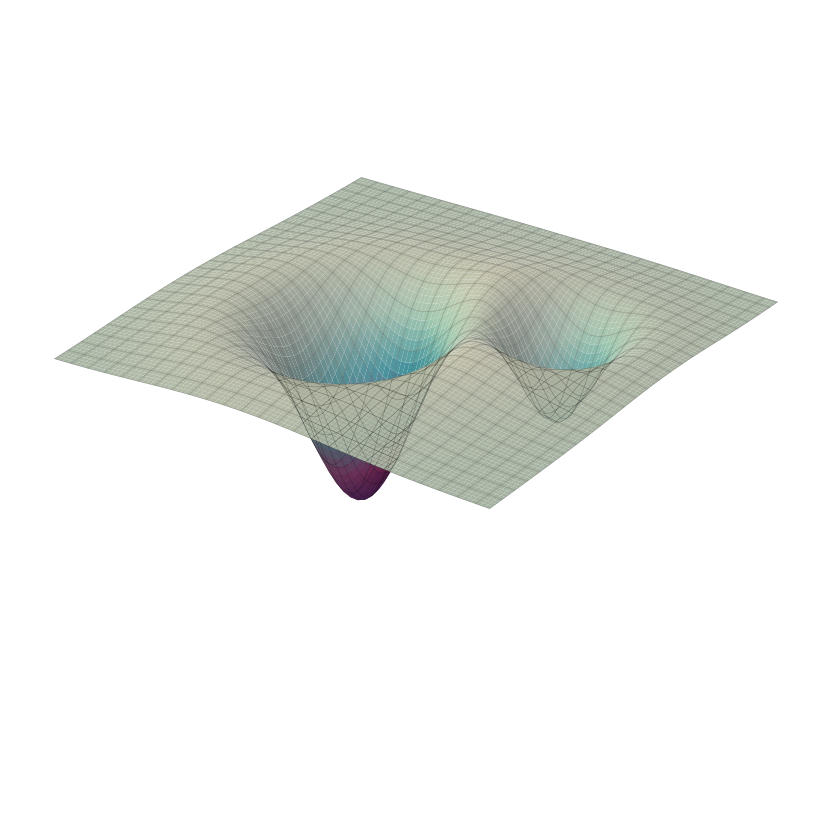

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

# ==========================================
# --- 設定エリア（ここを書き換えて選択します） ---
# ==========================================
ELEV_ANGLE = 28            # 視点の仰角 (上下。例: 10で低く、60で高く)
AZIM_ANGLE = -55           # 視点の方位角 (回転。例: 0〜360、マイナスも可)
ZOOM_LEVEL = 1.0           # ズーム倍率 (例: 1.5で拡大、0.8で縮小)
IS_BLACK_WHITE = False     # 白黒にする場合は True
TRANSPARENT_SURFACE = False # 曲面を半透明にして、下のワイヤーフレームを透けさせる場合は True
# ↑↑↑ 今回の画像の問題を解決するため、False（不透明）に設定します ↑↑↑
# ==========================================

# --- 1. 目的関数の定義 (ガウス差分モデル) ---
def objective_function(X, Y):
    r1_sq = (X - (-0.5))**2 + (Y - (-0.5))**2
    r2_sq = (X - 2.5)**2 + (Y - 1.2)**2
    Z1 = -2.2 * np.exp(-r1_sq / 2.0) + 0.6 * np.exp(-r1_sq / 8.0)
    Z2 = -1.2 * np.exp(-r2_sq / 1.0) + 0.3 * np.exp(-r2_sq / 4.0)
    return Z1 + Z2

x = np.linspace(-4.5, 5.0, 100)
y = np.linspace(-4.0, 4.5, 100)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 2. 色と陰影の処理 ---
if IS_BLACK_WHITE:
    # 白黒が選択された場合：ベース色を明るいグレーにする
    base_rgb = np.ones(Z.shape + (3,)) * 0.85
else:
    # 通常時：玉虫色カラーマップ
    colors = ['#4a1f59', '#9e457d', '#59aebb', '#bde0cc', '#f0eed1']
    iri_cmap = LinearSegmentedColormap.from_list("iridescent", colors)
    norm_Z = (Z - Z.min()) / (Z.max() - Z.min())
    base_rgb = iri_cmap(norm_Z)[:, :, :3]

# 光源計算 (陰影をつける)
ls = LightSource(azdeg=115, altdeg=45)
shaded = ls.shade_rgb(base_rgb, Z, blend_mode='soft', vert_exag=1.2)

# 透過設定の適用
# 曲面を半透明(0.6)にするか、不透明(1.0)にするかを設定値から決定
alpha_value = 0.6 if TRANSPARENT_SURFACE else 1.0

# Matplotlibの仕様上、色配列に直接アルファチャンネル(透明度)を追加するのが最も確実です
if shaded.shape[2] == 3:
    alpha_channel = np.full((shaded.shape[0], shaded.shape[1], 1), alpha_value)
    shaded_rgba = np.concatenate((shaded, alpha_channel), axis=2)
else:
    shaded_rgba = shaded
    shaded_rgba[:, :, 3] = alpha_value

# --- 3. 描画 ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 【修正点】 zorder を指定して描画順序を制御します
# 曲面の zorder を高く（例: 2）
surf = ax.plot_surface(X, Y, Z, facecolors=shaded_rgba, linewidth=0, antialiased=True, rstride=1, cstride=1, zorder=2)
# ワイヤーフレームの zorder を低く（例: 1）
ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4, color='black', alpha=0.3, linewidth=0.4, zorder=1)
# これにより、不透明な曲面が常に手前に描画され、奥にあるワイヤーフレームの線が透けて見えなくなります.

# --- 4. ズームの計算と適用 ---
x_mid, y_mid = (X.max() + X.min()) / 2, (Y.max() + Y.min()) / 2
x_range, y_range = X.max() - X.min(), Y.max() - Y.min()
z_mid = (Z.max() + Z.min()) / 2
z_range = (Z.max() - Z.min()) + 1.5

ax.set_xlim(x_mid - (x_range / 2) / ZOOM_LEVEL, x_mid + (x_range / 2) / ZOOM_LEVEL)
ax.set_ylim(y_mid - (y_range / 2) / ZOOM_LEVEL, y_mid + (y_range / 2) / ZOOM_LEVEL)
ax.set_zlim(z_mid - (z_range / 2) / ZOOM_LEVEL, z_mid + (z_range / 2) / ZOOM_LEVEL)

# --- 5. 視点（アングル）の適用 ---
ax.view_init(elev=ELEV_ANGLE, azim=AZIM_ANGLE)

# クリーンアップ
ax.set_facecolor('white')
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

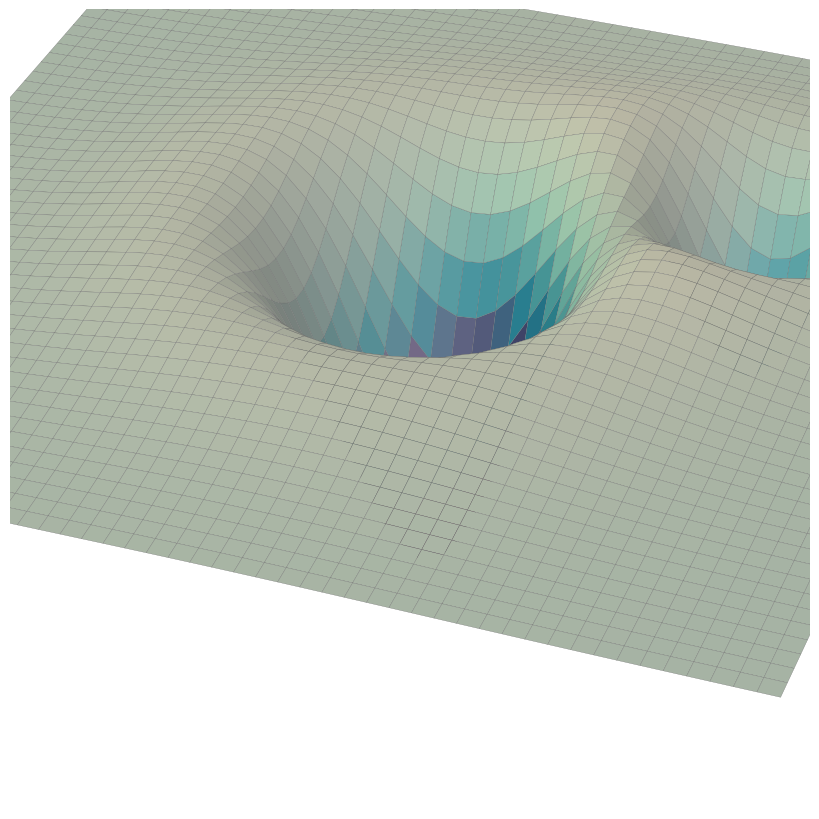

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

# ==========================================
# --- 設定エリア ---
# ==========================================
ELEV_ANGLE = 35            # 視点の仰角
AZIM_ANGLE = -70           # 視点の方位角
ZOOM_LEVEL = 2.0           # ズーム倍率
IS_BLACK_WHITE = False     # 白黒（石膏風）にする場合は True
# ==========================================

def objective_function(X, Y):
    r1_sq = (X - (-0.5))**2 + (Y - (-0.5))**2
    r2_sq = (X - 2.5)**2 + (Y - 1.2)**2
    Z1 = -2.2 * np.exp(-r1_sq / 2.0) + 0.6 * np.exp(-r1_sq / 8.0)
    Z2 = -1.2 * np.exp(-r2_sq / 1.0) + 0.3 * np.exp(-r2_sq / 4.0)
    return Z1 + Z2

x = np.linspace(-6, 5.0, 50)
y = np.linspace(-6.0, 4.5, 50)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 色と陰影の処理 ---
if IS_BLACK_WHITE:
    base_rgb = np.ones(Z.shape + (3,)) * 0.85
else:
    colors = ['#4a1f59', '#9e457d', '#59aebb', '#bde0cc', '#f0eed1']
    iri_cmap = LinearSegmentedColormap.from_list("iridescent", colors)
    norm_Z = (Z - Z.min()) / (Z.max() - Z.min())
    base_rgb = iri_cmap(norm_Z)[:, :, :3]

ls = LightSource(azdeg=115, altdeg=45)
shaded = ls.shade_rgb(base_rgb, Z, blend_mode='soft', vert_exag=1.2)

# --- 描画 ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

# 【修正点】
# 1. edgecolorを透過(RGBA)ではなく不透明な単色('dimgray')に変更
# 2. antialiased=False に変更し、境界の意図しないピクセルブレンドを防止
ax.plot_surface(
    X, Y, Z,
    facecolors=shaded,
    edgecolor='dimgray',
    linewidth=0.2,
    antialiased=True,
    rstride=1, cstride=1
)

# --- ズームの計算と適用 ---
x_mid, y_mid = (X.max() + X.min()) / 2, (Y.max() + Y.min()) / 2
x_range, y_range = X.max() - X.min(), Y.max() - Y.min()
z_mid = (Z.max() + Z.min()) / 2
z_range = (Z.max() - Z.min()) + 1.5

ax.set_xlim(x_mid - (x_range / 2) / ZOOM_LEVEL, x_mid + (x_range / 2) / ZOOM_LEVEL)
ax.set_ylim(y_mid - (y_range / 2) / ZOOM_LEVEL, y_mid + (y_range / 2) / ZOOM_LEVEL)
ax.set_zlim(z_mid - (z_range / 2) / ZOOM_LEVEL, z_mid + (z_range / 2) / ZOOM_LEVEL)

# --- 視点（アングル）の適用 ---
ax.view_init(elev=ELEV_ANGLE, azim=AZIM_ANGLE)

ax.set_facecolor('white')
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

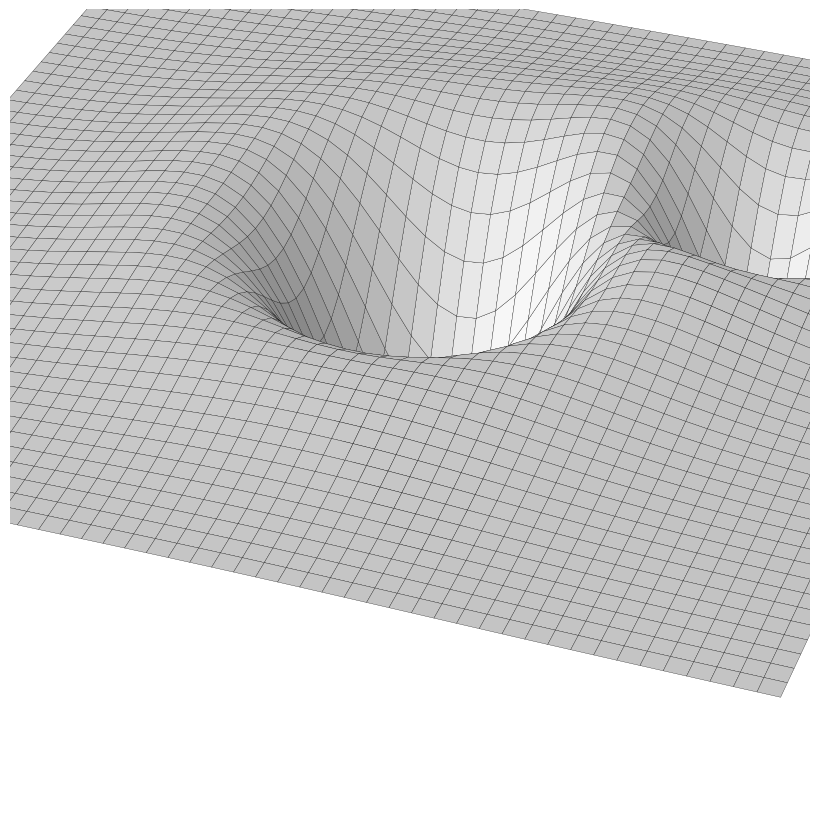

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

# ==========================================
# --- 設定エリア ---
# ==========================================
ELEV_ANGLE = 35            # 視点の仰角
AZIM_ANGLE = -70           # 視点の方位角
ZOOM_LEVEL = 2.0           # ズーム倍率
IS_BLACK_WHITE = True      # 白黒（石膏風）にする場合は True
# ==========================================

def objective_function(X, Y):
    r1_sq = (X - (-0.5))**2 + (Y - (-0.5))**2
    r2_sq = (X - 2.5)**2 + (Y - 1.2)**2
    Z1 = -2.2 * np.exp(-r1_sq / 2.0) + 0.6 * np.exp(-r1_sq / 8.0)
    Z2 = -1.2 * np.exp(-r2_sq / 1.0) + 0.3 * np.exp(-r2_sq / 4.0)
    return Z1 + Z2

x = np.linspace(-6, 5.0, 50)
y = np.linspace(-6.0, 4.5, 50)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 描画 ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

if IS_BLACK_WHITE:
    # 白黒モード：純白の曲面に黒の線（立体感を出すためのデフォルトの微細な陰影のみ残る）
    ax.plot_surface(
        X, Y, Z,
        color='white',
        edgecolor='black',
        linewidth=0.2,
        antialiased=True,
        rstride=1, cstride=1
    )
else:
    # 玉虫色モード：カスタム光源による陰影とカラーマップ
    colors = ['#4a1f59', '#9e457d', '#59aebb', '#bde0cc', '#f0eed1']
    iri_cmap = LinearSegmentedColormap.from_list("iridescent", colors)
    norm_Z = (Z - Z.min()) / (Z.max() - Z.min())
    base_rgb = iri_cmap(norm_Z)[:, :, :3]

    ls = LightSource(azdeg=115, altdeg=45)
    shaded = ls.shade_rgb(base_rgb, Z, blend_mode='soft', vert_exag=1.2)

    ax.plot_surface(
        X, Y, Z,
        facecolors=shaded,
        edgecolor='dimgray',
        linewidth=0.2,
        antialiased=True,
        rstride=1, cstride=1
    )

# --- ズームの計算と適用 ---
x_mid, y_mid = (X.max() + X.min()) / 2, (Y.max() + Y.min()) / 2
x_range, y_range = X.max() - X.min(), Y.max() - Y.min()
z_mid = (Z.max() + Z.min()) / 2
z_range = (Z.max() - Z.min()) + 1.5

ax.set_xlim(x_mid - (x_range / 2) / ZOOM_LEVEL, x_mid + (x_range / 2) / ZOOM_LEVEL)
ax.set_ylim(y_mid - (y_range / 2) / ZOOM_LEVEL, y_mid + (y_range / 2) / ZOOM_LEVEL)
ax.set_zlim(z_mid - (z_range / 2) / ZOOM_LEVEL, z_mid + (z_range / 2) / ZOOM_LEVEL)

# --- 視点（アングル）の適用 ---
ax.view_init(elev=ELEV_ANGLE, azim=AZIM_ANGLE)

ax.set_facecolor('white')
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

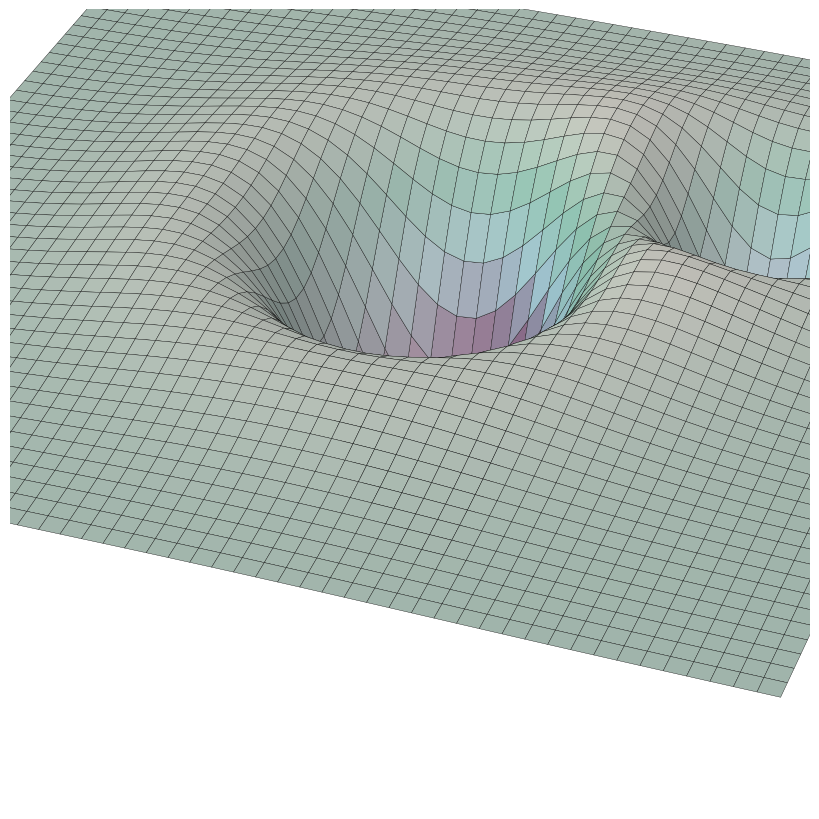

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

# ==========================================
# --- 設定エリア ---
# ==========================================
ELEV_ANGLE = 35            # 視点の仰角
AZIM_ANGLE = -70           # 視点の方位角
ZOOM_LEVEL = 2.0           # ズーム倍率
IS_BLACK_WHITE = False     # 白黒（石膏風）にする場合は True
SURFACE_LIGHTNESS = 0.6    # 地形の色の薄さ（0.0で元の濃い色、1.0で真っ白。0.4〜0.7あたりが綺麗な淡い色になります）
LINE_COLOR = 'black'       # 線の色（黒に戻しました）
LINE_WIDTH = 0.25          # 線の太さ
# ==========================================

def objective_function(X, Y):
    r1_sq = (X - (-0.5))**2 + (Y - (-0.5))**2
    r2_sq = (X - 2.5)**2 + (Y - 1.2)**2
    Z1 = -2.2 * np.exp(-r1_sq / 2.0) + 0.6 * np.exp(-r1_sq / 8.0)
    Z2 = -1.2 * np.exp(-r2_sq / 1.0) + 0.3 * np.exp(-r2_sq / 4.0)
    return Z1 + Z2

x = np.linspace(-6, 5.0, 50)
y = np.linspace(-6.0, 4.5, 50)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 描画 ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

if IS_BLACK_WHITE:
    # 白黒モード
    ax.plot_surface(
        X, Y, Z,
        color='white',
        edgecolor=LINE_COLOR,
        linewidth=LINE_WIDTH,
        antialiased=True,
        rstride=1, cstride=1
    )
else:
    # 玉虫色モード
    colors = [
        '#0b042b',  # 深淵のネイビー
        '#9c276a',  # マゼンタ
        '#4a154b',  # プラム/紫
        '#76b4c4',  # 水色
        '#4bb38d',  # ミントグリーン
        '#f0eed1'   # ペールイエロー
    ]
    iridescent_cmap = LinearSegmentedColormap.from_list("iridescent_complex", colors)

    norm_Z = (Z - Z.min()) / (Z.max() - Z.min())
    base_rgb = iridescent_cmap(norm_Z)[:, :, :3]

    # 【修正点】ベースの色に白をブレンドして、色合いを不透明なまま淡く（薄く）する
    white_rgb = np.ones_like(base_rgb)
    base_rgb = base_rgb * (1.0 - SURFACE_LIGHTNESS) + white_rgb * SURFACE_LIGHTNESS

    ls = LightSource(azdeg=115, altdeg=45)
    shaded = ls.shade_rgb(base_rgb, Z, blend_mode='soft', vert_exag=1.2)

    ax.plot_surface(
        X, Y, Z,
        facecolors=shaded,
        edgecolor=LINE_COLOR,
        linewidth=LINE_WIDTH,
        antialiased=True,
        rstride=1, cstride=1
    )

# --- ズームとアングルの適用 ---
x_mid, y_mid = (X.max() + X.min()) / 2, (Y.max() + Y.min()) / 2
x_range, y_range = X.max() - X.min(), Y.max() - Y.min()
z_mid = (Z.max() + Z.min()) / 2
z_range = (Z.max() - Z.min()) + 1.5

ax.set_xlim(x_mid - (x_range / 2) / ZOOM_LEVEL, x_mid + (x_range / 2) / ZOOM_LEVEL)
ax.set_ylim(y_mid - (y_range / 2) / ZOOM_LEVEL, y_mid + (y_range / 2) / ZOOM_LEVEL)
ax.set_zlim(z_mid - (z_range / 2) / ZOOM_LEVEL, z_mid + (z_range / 2) / ZOOM_LEVEL)

ax.view_init(elev=ELEV_ANGLE, azim=AZIM_ANGLE)

ax.set_facecolor('white')
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

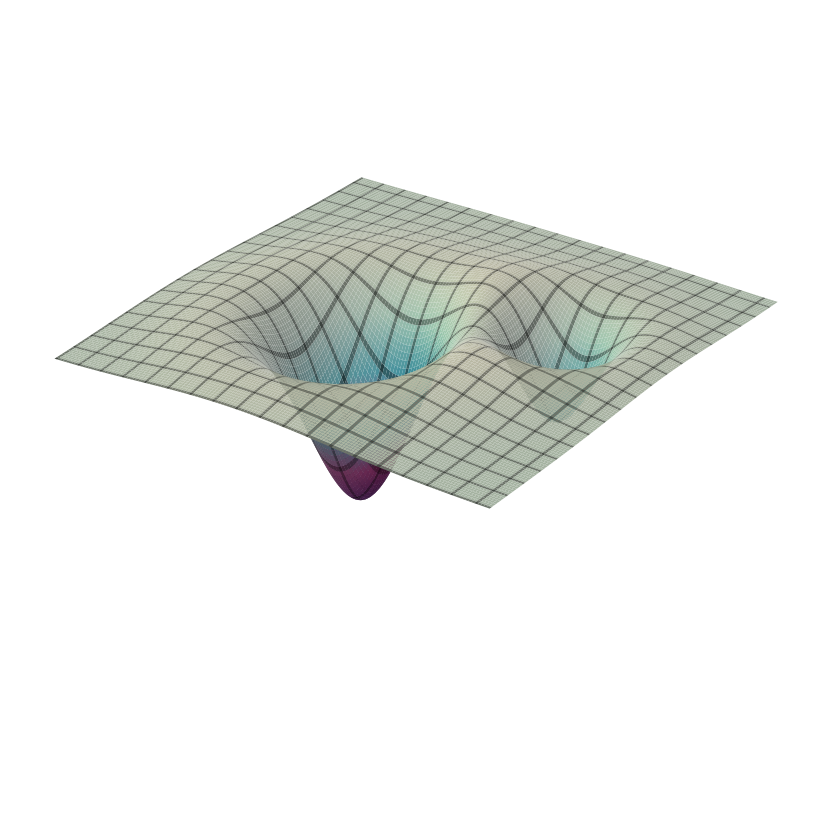

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap

# ==========================================
# --- 設定エリア ---
# ==========================================
ELEV_ANGLE = 28            # 視点の仰角
AZIM_ANGLE = -55           # 視点の方位角
ZOOM_LEVEL = 1.0           # ズーム倍率
IS_BLACK_WHITE = False     # 白黒（石膏風）にする場合は True
GRID_SPACING = 8           # 線の間隔（数字を大きくするほど線がまばらになります）
LINE_THICKNESS = 1         # 線の太さ（1が細い、2や3にすると太くくっきりします）
# ==========================================

def objective_function(X, Y):
    r1_sq = (X - (-0.5))**2 + (Y - (-0.5))**2
    r2_sq = (X - 2.5)**2 + (Y - 1.2)**2
    Z1 = -2.2 * np.exp(-r1_sq / 2.0) + 0.6 * np.exp(-r1_sq / 8.0)
    Z2 = -1.2 * np.exp(-r2_sq / 1.0) + 0.3 * np.exp(-r2_sq / 4.0)
    return Z1 + Z2

RESOLUTION = 150
x = np.linspace(-4.5, 5.0, RESOLUTION)
y = np.linspace(-4.0, 4.5, RESOLUTION)
X, Y = np.meshgrid(x, y)
Z = objective_function(X, Y)

# --- 色と陰影の処理 ---
if IS_BLACK_WHITE:
    base_rgb = np.ones(Z.shape + (3,)) * 0.85
else:
    colors = ['#4a1f59', '#9e457d', '#59aebb', '#bde0cc', '#f0eed1']
    iri_cmap = LinearSegmentedColormap.from_list("iridescent", colors)
    norm_Z = (Z - Z.min()) / (Z.max() - Z.min())
    base_rgb = iri_cmap(norm_Z)[:, :, :3]

ls = LightSource(azdeg=115, altdeg=45)
shaded = ls.shade_rgb(base_rgb, Z, blend_mode='soft', vert_exag=1.2)

# ==========================================
# 【新アプローチ】テクスチャに直接グリッドを描き込む
# ==========================================
face_colors = shaded[:-1, :-1, :].copy()
line_color = np.array([0.0, 0.0, 0.0])  # 線の色（黒）
line_alpha = 0.35                       # 線の濃さ（透過度）

# 指定された太さ(LINE_THICKNESS)分だけ、ピクセルを黒く塗り替える
for i in range(LINE_THICKNESS):
    # 横線を引く (iピクセル分ズラしながら塗る)
    face_colors[i::GRID_SPACING, :, :] = face_colors[i::GRID_SPACING, :, :] * (1 - line_alpha) + line_color * line_alpha
    # 縦線を引く
    face_colors[:, i::GRID_SPACING, :] = face_colors[:, i::GRID_SPACING, :] * (1 - line_alpha) + line_color * line_alpha
# ==========================================

# --- 描画 ---
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(projection='3d')

ax.plot_surface(
    X, Y, Z,
    facecolors=face_colors,
    edgecolor='none',
    linewidth=0,
    antialiased=True,
    rstride=1, cstride=1
)

# --- ズームの計算と適用 ---
x_mid, y_mid = (X.max() + X.min()) / 2, (Y.max() + Y.min()) / 2
x_range, y_range = X.max() - X.min(), Y.max() - Y.min()
z_mid = (Z.max() + Z.min()) / 2
z_range = (Z.max() - Z.min()) + 1.5

ax.set_xlim(x_mid - (x_range / 2) / ZOOM_LEVEL, x_mid + (x_range / 2) / ZOOM_LEVEL)
ax.set_ylim(y_mid - (y_range / 2) / ZOOM_LEVEL, y_mid + (y_range / 2) / ZOOM_LEVEL)
ax.set_zlim(z_mid - (z_range / 2) / ZOOM_LEVEL, z_mid + (z_range / 2) / ZOOM_LEVEL)

# --- 視点（アングル）の適用 ---
ax.view_init(elev=ELEV_ANGLE, azim=AZIM_ANGLE)

ax.set_facecolor('white')
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()